# Simple baseline model

In [20]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" /  "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" / "processed"

##### Load the dataset

In [22]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "pmdata_daily_features.parquet")

In [23]:
target = "readiness"

In [24]:
df.columns

Index(['participant_id', 'date', 'steps_daily', 'sleep_minutes', 'time_in_bed',
       'sleep_efficiency', 'hr_mean', 'hr_min', 'hr_max', 'hr_std',
       'resting_heart_rate', 'calories_daily', 'mood', 'fatigue', 'stress',
       'sleep_quality', 'readiness'],
      dtype='object')

In [25]:
feature_cols = [
    "steps_daily",
    "sleep_minutes",
    "time_in_bed",
    "sleep_efficiency",
    "hr_mean",
    "hr_min",
    "hr_max",
    "hr_std",
    "resting_heart_rate",
    "calories_daily",
    "mood",
]


In [26]:
model_df = df.dropna(subset=[target])


#### Train-Test Split

In [27]:
X = model_df[feature_cols]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [28]:
print(X.shape, y.shape)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1729, 11) (1729,)
(1383, 11) (1383,) (346, 11) (346,)


#### Analysis of the training data

In [29]:
X_train.isna().mean().sort_values(ascending=False)

resting_heart_rate    0.212581
time_in_bed           0.138106
sleep_minutes         0.138106
sleep_efficiency      0.138106
hr_max                0.032538
hr_min                0.032538
hr_mean               0.032538
hr_std                0.032538
calories_daily        0.028200
steps_daily           0.005061
mood                  0.000000
dtype: float64

 `mood` has no missing values, and `steps_daily` is almost complete with only about 0.5% missing data.

The highest missingness is in `resting_heart_rate`, where about 21.3% of values are missing. 

Sleep-related features (`time_in_bed`, `sleep_minutes`, and `sleep_efficiency`) each have about 13.8% missingness, because sleep records are not available for every day.

Heart-rate summary features have around 3.3% missing values, and daily calories have about 2.8% missingness.

array([[<Axes: title={'center': 'steps_daily'}>,
        <Axes: title={'center': 'sleep_minutes'}>,
        <Axes: title={'center': 'time_in_bed'}>],
       [<Axes: title={'center': 'sleep_efficiency'}>,
        <Axes: title={'center': 'hr_mean'}>,
        <Axes: title={'center': 'hr_min'}>],
       [<Axes: title={'center': 'hr_max'}>,
        <Axes: title={'center': 'hr_std'}>,
        <Axes: title={'center': 'resting_heart_rate'}>],
       [<Axes: title={'center': 'calories_daily'}>,
        <Axes: title={'center': 'mood'}>, <Axes: >]], dtype=object)

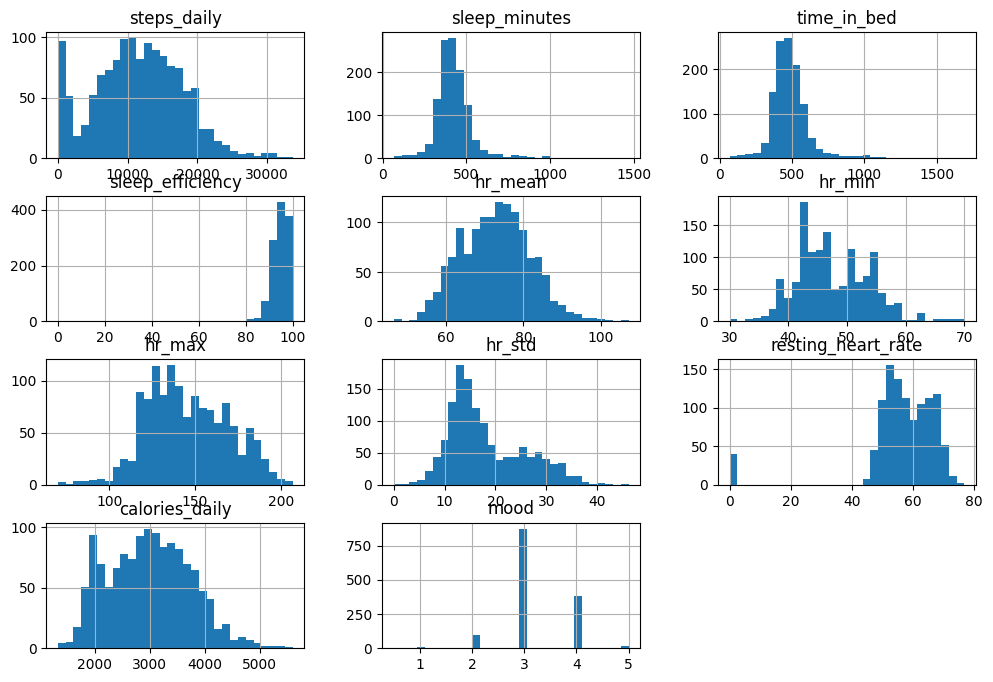

In [30]:
X_train.hist(figsize=(12, 8), bins=30)

Most features have reasonable ranges, but several are skewed or contain outliers. 

Daily steps and calories are right-skewed, which is expected because some days have unusually high activity. 


Sleep features mostly cluster around typical nightly sleep ranges, though there are a few very large values that may represent long sleep periods, naps, or aggregation artifacts.

Heart-rate features appear mostly plausible, with average heart rate centered around the 60-80 bpm range. 

`hr_std` is right-skewed, suggesting some days had much more heart-rate variability, possibly due to exercise or inconsistent wear time. 


`mood` is discrete and heavily concentrated around 3 and 4, meaning the model has limited variation from this feature.


In [31]:
corr_df = pd.concat([X_train, y_train.rename("readiness")], axis=1)
corr_df.corr(numeric_only=True)["readiness"].sort_values(ascending=False)

readiness             1.000000
mood                  0.196624
hr_max                0.166165
hr_std                0.161126
sleep_efficiency      0.116103
steps_daily           0.095391
calories_daily        0.081928
time_in_bed           0.038720
sleep_minutes         0.031335
hr_mean              -0.036542
hr_min               -0.060715
resting_heart_rate   -0.086312
Name: readiness, dtype: float64

<Axes: >

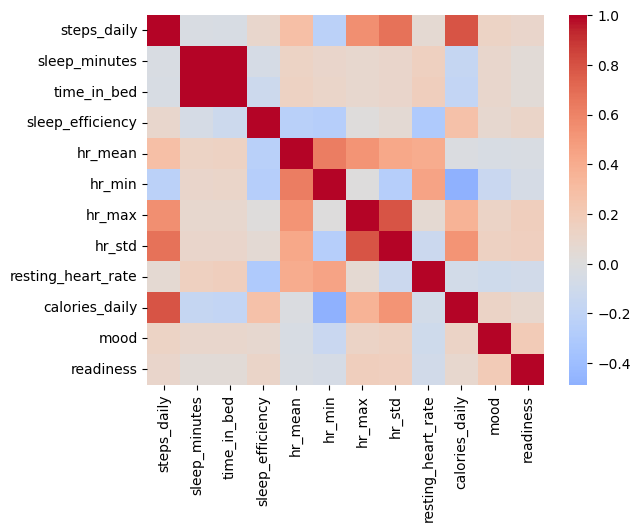

In [32]:
sns.heatmap(corr_df.corr(numeric_only=True), cmap="coolwarm", center=0)


`sleep_minutes` and `time_in_bed` are almost perfectly correlated, which is obvious thing. 
 
 
Daily steps and calories are positively correlated, which makes sense because more activity usually burns more calories.

Heart-rate features also show relationships: `hr_mean`, `hr_max`, and `hr_std` are positively related, while `hr_min` behaves somewhat differently. 

Readiness does not show a very strong linear correlation with any single feature, suggesting that readiness may depend on a combination of signals rather than one simple feature.

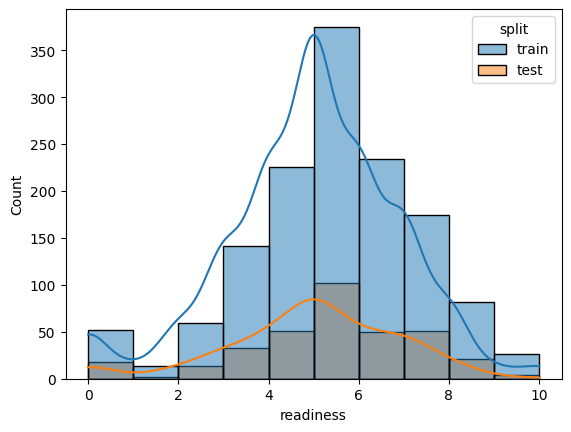

In [33]:
# checkig the labels

plot_df = pd.DataFrame({
    "readiness": pd.concat([y_train, y_test]),
    "split": ["train"] * len(y_train) + ["test"] * len(y_test)
})

sns.histplot(data=plot_df, x="readiness", hue="split", bins=10, kde=True)
plt.show()


The readiness target is concentrated mostly between 4 and 7, with fewer samples at the very low and very high ends. 

The train and test distributions follow a similar shape:
    
   -  the random split preserved the overall target distribution reasonably well.

 However, extreme readiness values are underrepresented, 
    
   - so model performance may be weaker for unusually low or high readiness days.

In [34]:
pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})


,train,test
count,1383.000000,346.000000
mean,4.961316,4.927746
std,1.913030,1.945037
min,0.000000,0.000000
25%,4.000000,4.000000
50%,5.000000,5.000000
75%,6.000000,6.000000
max,10.000000,10.000000


In [35]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

mae

1.2678294589161643

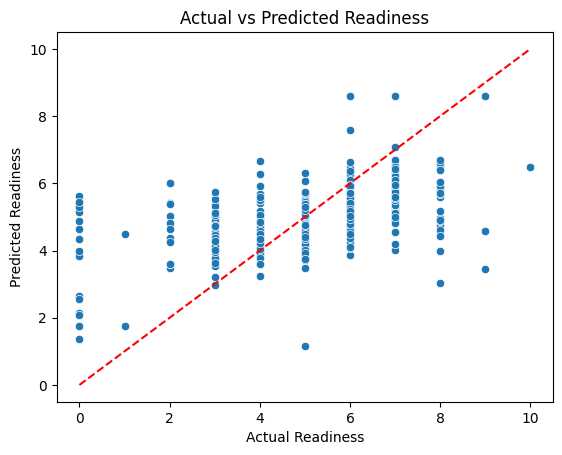

In [36]:
results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})

sns.scatterplot(data=results_df, x="actual", y="predicted")
plt.plot(
    [results_df["actual"].min(), results_df["actual"].max()],
    [results_df["actual"].min(), results_df["actual"].max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Readiness")
plt.ylabel("Predicted Readiness")
plt.title("Actual vs Predicted Readiness")
plt.show()

The model captures the general middle range of readiness scores, 
- but predictions are compressed toward the center. 

- Very low and very high actual readiness values are not predicted as strongly

-  the model tends to overpredict low readiness days and underpredict high readiness days.

- model struggles with extreme readiness values, 
    - maybe because most training examples are concentrated in the mid-range.


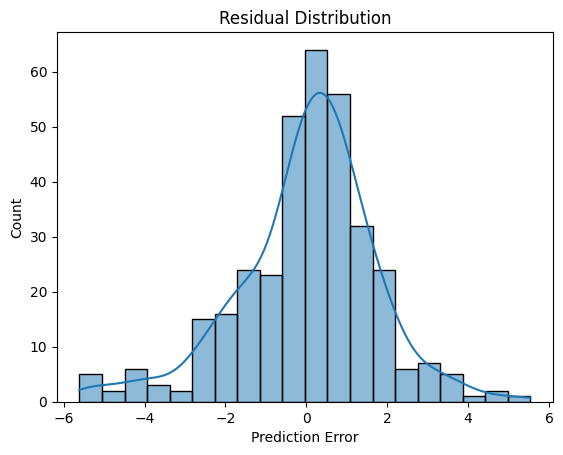

In [37]:
results_df["error"] = results_df["actual"] - results_df["predicted"]

sns.histplot(results_df["error"], bins=20, kde=True)
plt.xlabel("Prediction Error")
plt.title("Residual Distribution")
plt.show()


Most errors are clustered around zero 
    
- model is usually close to the true readiness score. 
    
The baseline still makes some large errors.


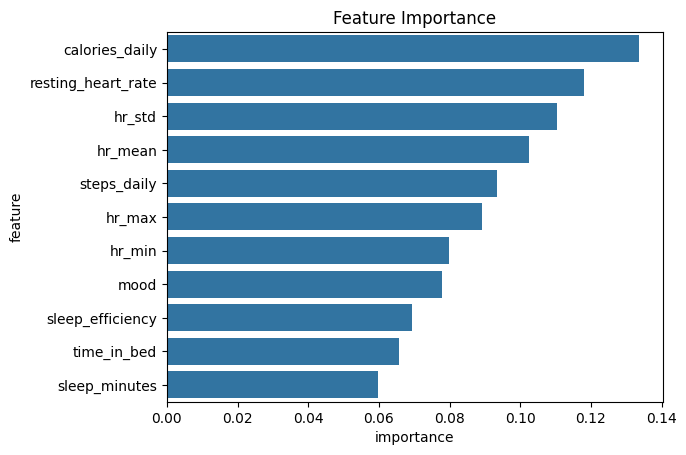

In [38]:
importances = model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()
